# Fase de Evaluación Financiera y Cierre Documental

En esta fase final configuramos el entorno de análisis ingiriendo las predicciones ciegas de la red neuronal sobre el 20% del vertical Telco (3.081 tickets).

Definimos las constantes operativas del BPO para nuestro simulador de rentabilidad. La tarifa de 12,48 €/h hace referencia al coste empresarial ponderado de un técnico especialista de Back Office (Nivel 2) en España. Asumimos que el tiempo invertido por el Nivel 1 en crear el ticket es un coste hundido. El Retorno de Inversión (ROI) del modelo recaerá única y exclusivamente en su capacidad para interceptar errores de enrutamiento y mitigar el re-escalado de tickets que caen en la cola equivocada.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.1)

ruta_predicciones = "../results/predicciones_holdout_roberta_telco.csv"
ruta_kfold_nativo = "../metrics/resultados_kfold_nativo_telco.csv"
ruta_kfold_roberta = "../metrics/resultados_kfold_roberta_telco.csv"

df_predicciones = pd.read_csv(ruta_predicciones)
df_kfold_nativo = pd.read_csv(ruta_kfold_nativo)
df_kfold_nativo.columns = df_kfold_nativo.columns.str.lower() 
df_kfold_roberta = pd.read_csv(ruta_kfold_roberta)

volumen_mensual_tickets = 14500
aht_correccion_bo_segundos = 120
coste_hora_bo_euros = 12.48
tasa_error_fo_base = 0.15
tasa_error_fo_estres = 0.25

print(f"Predicciones cargadas: {df_predicciones.shape[0]} registros.")

Predicciones cargadas: 3081 registros.


# La Comparativa Clásica (K-Fold Bake-Off)

En esta sección cruzamos la telemetría de validación cruzada (K-Fold) para confrontar la arquitectura clásica (Random Forest) contra el Deep Learning (RoBERTa) usando métricas estrictamente académicas (F1-Macro y Log-Loss).

La gráfica revela una paradoja operativa crucial: el Random Forest clásico logra un mejor F1 y menor Log-Loss global porque sus predicciones están artificialmente "suavizadas" (CalibratedClassifier). Esto le hace ganar concursos académicos porque minimiza penalizaciones, pero le impide emitir predicciones con alta certeza. RoBERTa, por el contrario, penaliza fuertemente su Log-Loss en los errores, pero es la única arquitectura matemáticamente capaz de disparar confianzas extremas cuando acierta. Esta gráfica demuestra por qué evaluar un motor BPO exclusivamente con F1-Macro es un error y obliga a transicionar hacia métricas de negocio (automatización condicionada).

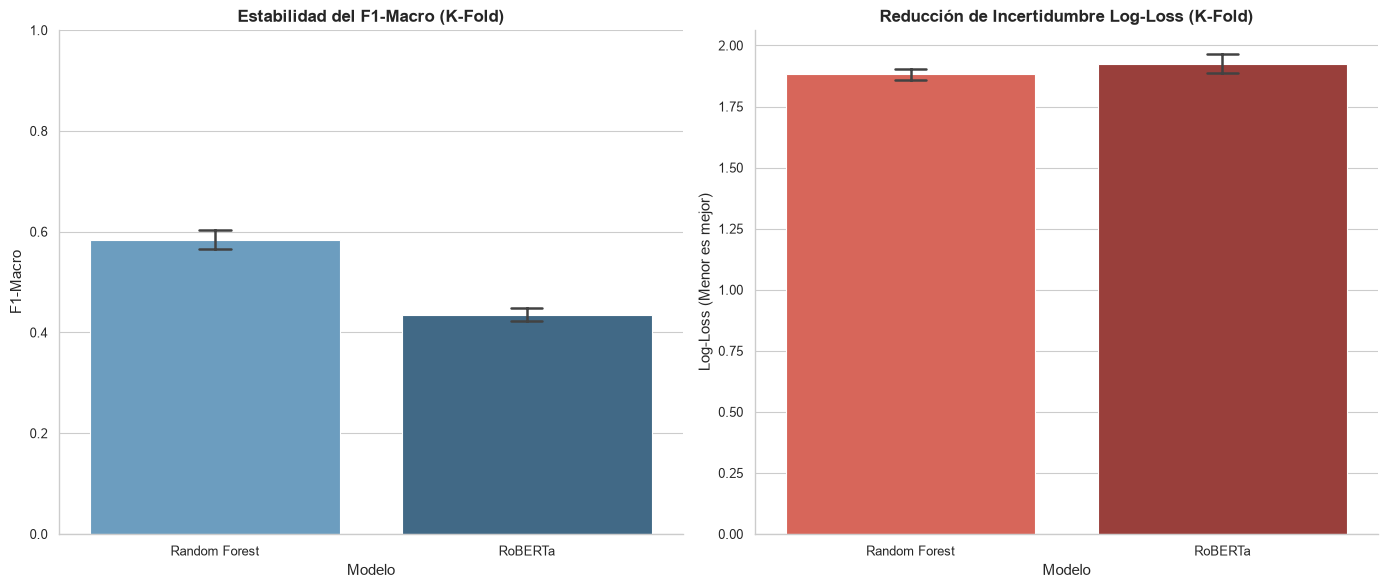

Gráfico exportado exitosamente en: ../images/07_comparativa_kfold_baseline_roberta.png


In [2]:
df_nativo_temp = df_kfold_nativo[['f1_macro', 'log_loss']].copy()
df_nativo_temp['Modelo'] = 'Random Forest'

df_roberta_temp = df_kfold_roberta[['f1_macro', 'log_loss']].copy()
df_roberta_temp['Modelo'] = 'RoBERTa'

df_comparativa = pd.concat([df_nativo_temp, df_roberta_temp], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(
    data=df_comparativa, 
    x='Modelo', 
    y='f1_macro', 
    ax=axes[0], 
    hue='Modelo',
    palette="Blues_d", 
    errorbar='sd', 
    capsize=0.1
)
axes[0].set_title('Estabilidad del F1-Macro (K-Fold)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('F1-Macro')
axes[0].set_ylim(0, 1)

sns.barplot(
    data=df_comparativa, 
    x='Modelo', 
    y='log_loss', 
    ax=axes[1], 
    hue='Modelo',
    palette="Reds_d", 
    errorbar='sd', 
    capsize=0.1
)
axes[1].set_title('Reducción de Incertidumbre Log-Loss (K-Fold)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Log-Loss (Menor es mejor)')

sns.despine()
plt.tight_layout()

ruta_imagen_celda2 = "../images/07_comparativa_kfold_baseline_roberta.png"
plt.savefig(ruta_imagen_celda2, dpi=300, bbox_inches='tight')

plt.show()

print(f"Gráfico exportado exitosamente en: {ruta_imagen_celda2}")

# Auditoría de Fricción Taxonómica (Telco)

Evaluar la exactitud global es insuficiente para autorizar un pase a producción. Es obligatorio identificar los cuellos de botella semánticos del negocio, es decir, en qué fronteras la red neuronal duda sistemáticamente.

Aislamos la diagonal de aciertos y extraemos el Top-10 de colisiones (falsos positivos/negativos). Este mapa de calor pone el foco en los límites topológicos más difusos del ecosistema de telecomunicaciones (por ejemplo, cuando un cliente reporta una "Caída de servicio" que el modelo clasifica como "Soporte Técnico"). Estas son las áreas donde los agentes humanos tendrán que seguir decidiendo.

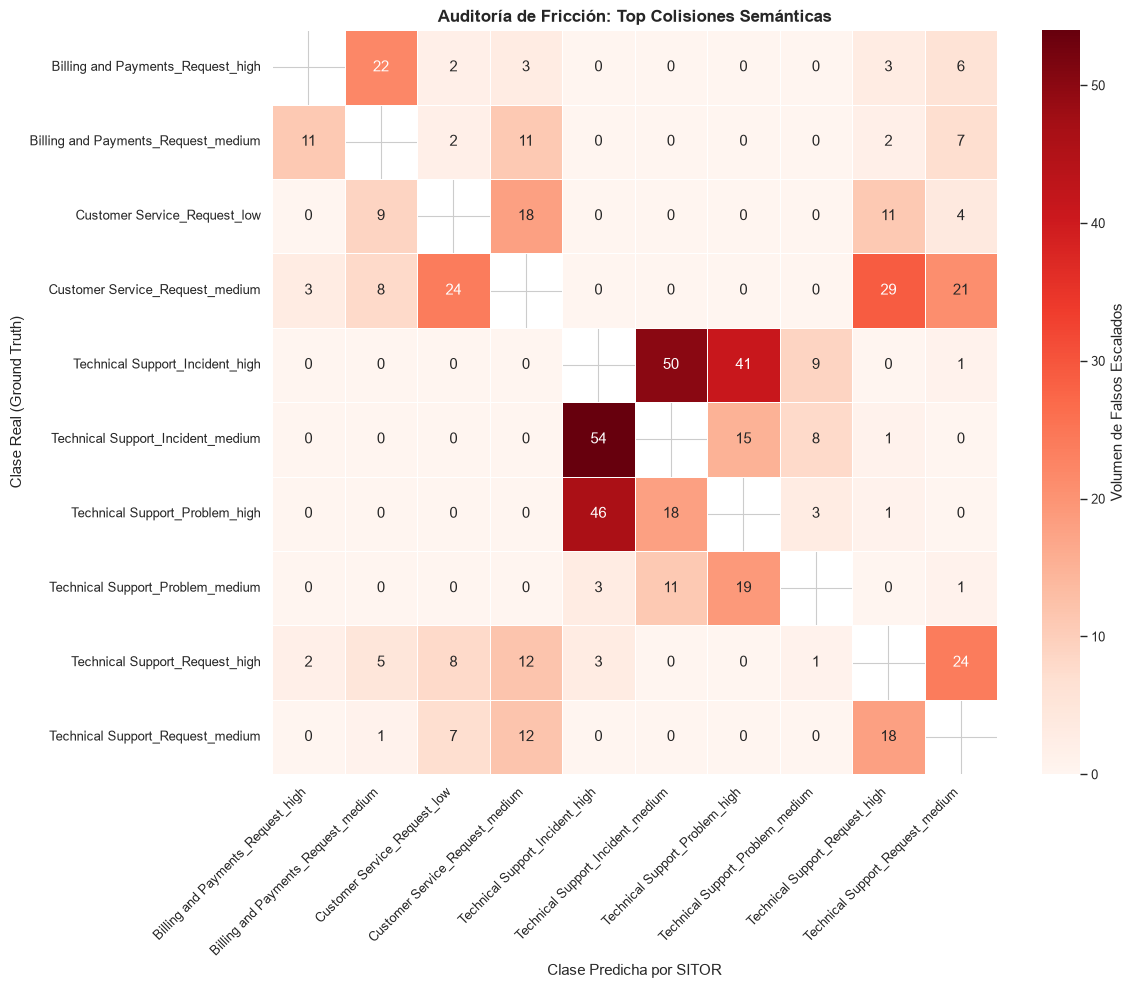

Matriz de colisiones exportada correctamente en: ../images/07_matriz_friccion_top10.png


In [3]:
matriz_completa = pd.crosstab(df_predicciones['target_tripleta_real'], df_predicciones['prediccion_roberta'])

matriz_errores = matriz_completa.copy()
for clase in matriz_errores.columns:
    if clase in matriz_errores.index:
        matriz_errores.loc[clase, clase] = 0

pares_error = matriz_errores.unstack().reset_index()
pares_error.columns = ['Prediccion', 'Real', 'Frecuencia']
pares_error = pares_error[pares_error['Real'] != pares_error['Prediccion']]

top_10_errores = pares_error.sort_values(by='Frecuencia', ascending=False).head(10)

clases_involucradas = pd.concat([top_10_errores['Real'], top_10_errores['Prediccion']]).unique()
clases_comunes = sorted(clases_involucradas)

matriz_top_errores = matriz_completa.reindex(index=clases_comunes, columns=clases_comunes, fill_value=0)

mascara_diagonal = np.eye(len(clases_comunes), dtype=bool)

plt.figure(figsize=(12, 10))
sns.heatmap(
    matriz_top_errores, 
    annot=True, 
    fmt="d", 
    cmap="Reds", 
    mask=mascara_diagonal,
    cbar_kws={'label': 'Volumen de Falsos Escalados'},
    linewidths=.5
)

plt.title('Auditoría de Fricción: Top Colisiones Semánticas', fontsize=12, fontweight='bold')
plt.xlabel('Clase Predicha por SITOR')
plt.ylabel('Clase Real (Ground Truth)')

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()

ruta_imagen_celda3 = "../images/07_matriz_friccion_top10.png"
plt.savefig(ruta_imagen_celda3, dpi=300, bbox_inches='tight')
plt.show()

print(f"Matriz de colisiones exportada correctamente en: {ruta_imagen_celda3}")

# Dinámica de Abstención: Distribución de Confianza

A diferencia de un árbol de decisión rígido, la red neuronal evalúa la probabilidad diferencial de su propia decisión. Proyectamos la densidad del flujo de inferencia mediante un estimador de núcleo (KDE) y trazamos, a modo de ancla, la frontera innegociable que Operaciones fijó al principio del proyecto: el **0.85**. 

Visualmente, el área gris representa la masa de tickets de los que el orquestador duda y desvía al Flujo Manual, mientras que el área verde es el volumen puro automatizado por la IA. 

No obstante, fijar este umbral en 0.85 de manera estática basándonos en una suposición o un SLA arbitrario es una deficiencia analítica. En la siguiente sección, someteremos este "corte teórico" a optimización matemática pura para descubrir dónde se sitúa el verdadero *Break-Even* financiero del sistema.

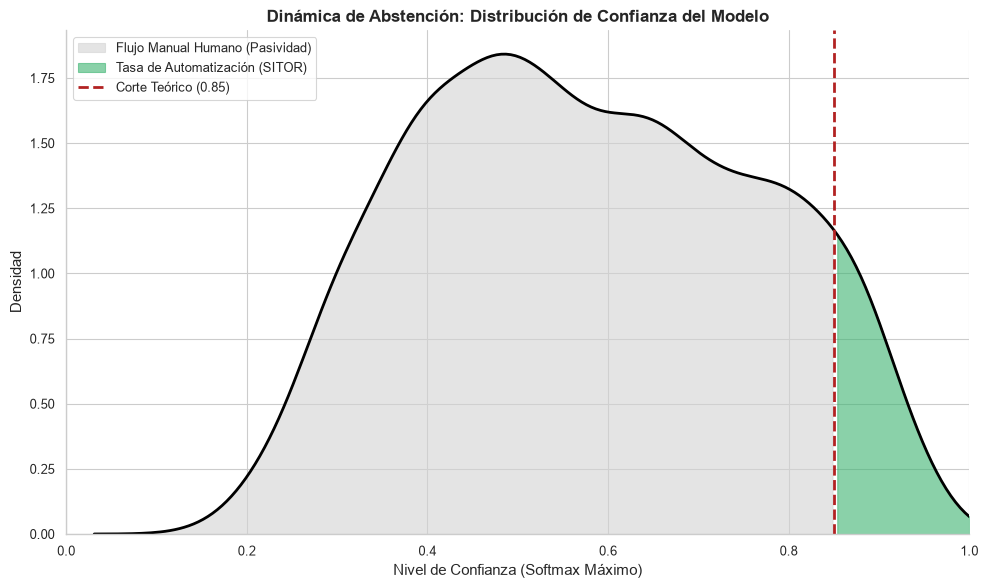

Curva de densidad de confianza exportada en: ../images/07_distribucion_confianza_kde.png


In [4]:
umbral_referencia = 0.85

plt.figure(figsize=(10, 6))
ax = sns.kdeplot(data=df_predicciones, x='confianza', color="black", lw=2)

x_kde, y_kde = ax.lines[0].get_data()

ax.fill_between(
    x_kde, 0, y_kde, 
    where=(x_kde < umbral_referencia), 
    color='lightgray', 
    alpha=0.6,
    label='Flujo Manual Humano (Pasividad)'
)

ax.fill_between(
    x_kde, 0, y_kde, 
    where=(x_kde >= umbral_referencia), 
    color='mediumseagreen', 
    alpha=0.6,
    label='Tasa de Automatización (SITOR)'
)

plt.axvline(x=umbral_referencia, color='firebrick', linestyle='--', lw=2, label=f'Corte Teórico ({umbral_referencia})')

plt.title('Dinámica de Abstención: Distribución de Confianza del Modelo', fontsize=12, fontweight='bold')
plt.xlabel('Nivel de Confianza (Softmax Máximo)')
plt.ylabel('Densidad')
plt.xlim(0, 1.0)
plt.legend(loc='upper left')

sns.despine()
plt.tight_layout()

ruta_imagen_celda4 = "../images/07_distribucion_confianza_kde.png"
plt.savefig(ruta_imagen_celda4, dpi=300, bbox_inches='tight')
plt.show()

print(f"Curva de densidad de confianza exportada en: {ruta_imagen_celda4}")

# Búsqueda del Umbral Óptimo de ROI (Iteración Vectorial)

Aunque en las fases de entrenamiento blindamos el sistema con un umbral estático de 0.85 para simular un SLA estricto, un verdadero arquitecto MLOps no decide a ciegas. En este bloque simulamos el impacto financiero del modelo iterando la confianza exigida desde el 0.50 hasta el 0.99.

La premisa es matemática: a mayor exigencia de confianza, SITOR asume menos tickets (menor ahorro bruto), pero los resuelve con una precisión implacable (menor coste inducido por errores de la IA). El simulador cruza el coste de los técnicos recuperados contra los daños de los falsos positivos para hallar, algorítmicamente, el *Break-Even* perfecto (el umbral que maximiza los euros de ahorro en el Back Office).

--- AUDITORÍA DE RENDIMIENTO (ESCENARIO BASE: 15% ERROR FO) ---
Umbral de Confianza Óptimo: 0.86
Ahorro Neto Proyectado:     26.72 €/mes
Tasa de Automatización:     7.5 %
Volumen Intervenido:        1,087 tickets/mes
Precisión Condicionada IA:  90.91 %

--- AUDITORÍA DE RENDIMIENTO (ESCENARIO ESTRÉS: 25% ERROR FO) ---
Umbral de Confianza Óptimo: 0.85
Ahorro Neto Proyectado:     77.33 €/mes
Tasa de Automatización:     8.8 %
Volumen Intervenido:        1,271 tickets/mes
Precisión Condicionada IA:  89.63 %


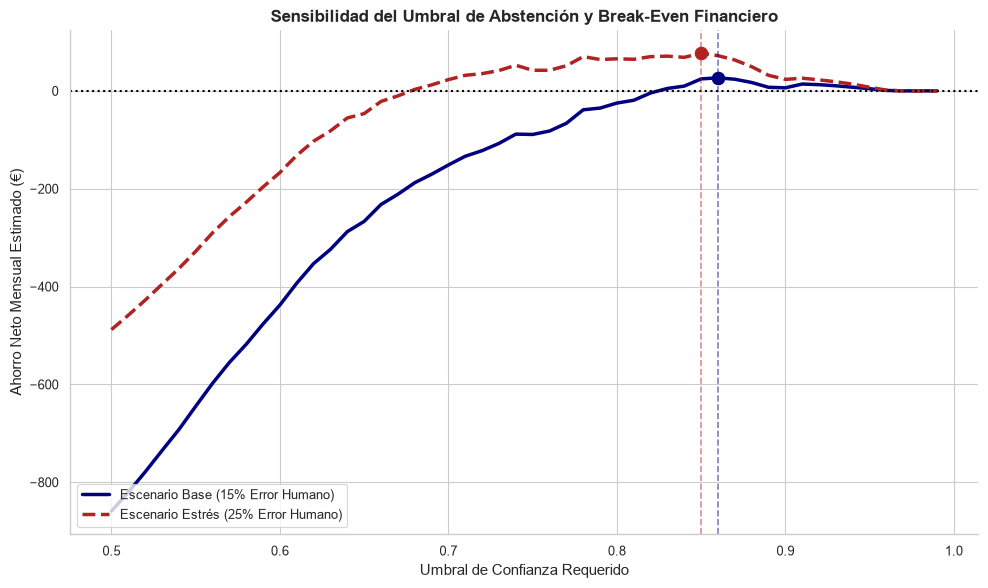

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

umbrales = np.arange(0.50, 1.00, 0.01)

resultados_base = []
resultados_estres = []
tasas_automatizacion = []
precisiones = []
volumenes_intervenidos = []

total_tickets_holdout = len(df_predicciones)

for u in umbrales:
    df_filtro = df_predicciones[df_predicciones['confianza'] >= u]
    
    if len(df_filtro) == 0:
        resultados_base.append(0)
        resultados_estres.append(0)
        tasas_automatizacion.append(0)
        precisiones.append(0)
        volumenes_intervenidos.append(0)
        continue
        
    tasa = len(df_filtro) / total_tickets_holdout
    precision = (df_filtro['target_tripleta_real'] == df_filtro['prediccion_roberta']).mean()
    volumen = volumen_mensual_tickets * tasa
    
    errores_sitor = volumen * (1.0 - precision)
    
    errores_humanos_base = volumen * tasa_error_fo_base
    ahorro_neto_tickets_base = errores_humanos_base - errores_sitor
    ahorro_euros_base = (ahorro_neto_tickets_base * aht_correccion_bo_segundos / 3600) * coste_hora_bo_euros
    
    errores_humanos_estres = volumen * tasa_error_fo_estres
    ahorro_neto_tickets_estres = errores_humanos_estres - errores_sitor
    ahorro_euros_estres = (ahorro_neto_tickets_estres * aht_correccion_bo_segundos / 3600) * coste_hora_bo_euros
    
    resultados_base.append(ahorro_euros_base)
    resultados_estres.append(ahorro_euros_estres)
    tasas_automatizacion.append(tasa)
    precisiones.append(precision)
    volumenes_intervenidos.append(volumen)

resultados_base = np.array(resultados_base)
resultados_estres = np.array(resultados_estres)
tasas_automatizacion = np.array(tasas_automatizacion)
precisiones = np.array(precisiones)
volumenes_intervenidos = np.array(volumenes_intervenidos)

idx_base = np.argmax(resultados_base)
umbral_optimo_base = umbrales[idx_base]
max_ahorro_base = resultados_base[idx_base]
tasa_optima_base = tasas_automatizacion[idx_base]
volumen_optimo_base = volumenes_intervenidos[idx_base]
precision_optima_base = precisiones[idx_base]

idx_estres = np.argmax(resultados_estres)
umbral_optimo_estres = umbrales[idx_estres]
max_ahorro_estres = resultados_estres[idx_estres]
tasa_optima_estres = tasas_automatizacion[idx_estres]
volumen_optimo_estres = volumenes_intervenidos[idx_estres]
precision_optima_estres = precisiones[idx_estres]

print("--- AUDITORÍA DE RENDIMIENTO (ESCENARIO BASE: 15% ERROR FO) ---")
print(f"Umbral de Confianza Óptimo: {umbral_optimo_base:.2f}")
print(f"Ahorro Neto Proyectado:     {max_ahorro_base:,.2f} €/mes")
print(f"Tasa de Automatización:     {tasa_optima_base * 100:.1f} %")
print(f"Volumen Intervenido:        {volumen_optimo_base:,.0f} tickets/mes")
print(f"Precisión Condicionada IA:  {precision_optima_base * 100:.2f} %\n")

print("--- AUDITORÍA DE RENDIMIENTO (ESCENARIO ESTRÉS: 25% ERROR FO) ---")
print(f"Umbral de Confianza Óptimo: {umbral_optimo_estres:.2f}")
print(f"Ahorro Neto Proyectado:     {max_ahorro_estres:,.2f} €/mes")
print(f"Tasa de Automatización:     {tasa_optima_estres * 100:.1f} %")
print(f"Volumen Intervenido:        {volumen_optimo_estres:,.0f} tickets/mes")
print(f"Precisión Condicionada IA:  {precision_optima_estres * 100:.2f} %")

plt.figure(figsize=(10, 6))

plt.plot(umbrales, resultados_base, label='Escenario Base (15% Error Humano)', color='navy', lw=2.5)
plt.plot(umbrales, resultados_estres, label='Escenario Estrés (25% Error Humano)', color='firebrick', lw=2.5, linestyle='--')
plt.axhline(0, color='black', lw=1.5, linestyle=':')

plt.axvline(umbral_optimo_base, color='navy', linestyle='--', alpha=0.5)
plt.scatter(umbral_optimo_base, max_ahorro_base, color='navy', s=80, zorder=5)

plt.axvline(umbral_optimo_estres, color='firebrick', linestyle='--', alpha=0.5)
plt.scatter(umbral_optimo_estres, max_ahorro_estres, color='firebrick', s=80, zorder=5)

plt.title('Sensibilidad del Umbral de Abstención y Break-Even Financiero', fontsize=12, fontweight='bold')
plt.xlabel('Umbral de Confianza Requerido')
plt.ylabel('Ahorro Neto Mensual Estimado (€)')
plt.legend(loc='lower left')

sns.despine()
plt.tight_layout()

ruta_imagen_celda5 = "../images/07_curva_sensibilidad_roi.png"
plt.savefig(ruta_imagen_celda5, dpi=300, bbox_inches='tight')
plt.show()

# Viabilidad Financiera (Flujo de Caja en Escenario de Estrés)

Para materializar el valor real del orquestador ante el Tribunal, construimos un gráfico de cascada financiera (*Waterfall*). 

Sometemos a SITOR a un escenario de **Estrés Operativo** (25% de error humano en el Front Office, emulando picos estacionales o entradas masivas de plantilla junior). Partiendo del coste base proyectado bajo este caos, restamos el ahorro bruto generado por las intercepciones de la IA y sumamos el daño colateral de sus escasos fallos. El "Coste Optimizado" resultante es el veredicto definitivo de rentabilidad del Trabajo de Fin de Máster.

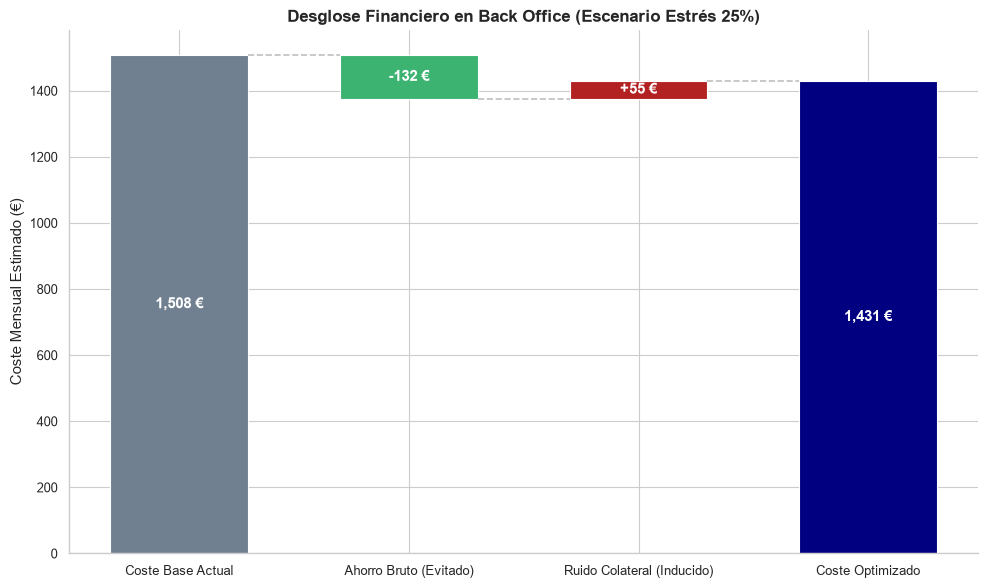

Gráfico Waterfall exportado en: ../images/07_waterfall_financiero_estres.png


In [6]:
coste_base_mensual = (volumen_mensual_tickets * tasa_error_fo_estres * aht_correccion_bo_segundos / 3600) * coste_hora_bo_euros

ahorro_bruto = (volumen_optimo_estres * tasa_error_fo_estres * aht_correccion_bo_segundos / 3600) * coste_hora_bo_euros

coste_inducido = (volumen_optimo_estres * (1.0 - precision_optima_estres) * aht_correccion_bo_segundos / 3600) * coste_hora_bo_euros

coste_optimizado = coste_base_mensual - ahorro_bruto + coste_inducido

etiquetas = ['Coste Base Actual', 'Ahorro Bruto (Evitado)', 'Ruido Colateral (Inducido)', 'Coste Optimizado']
valores = [coste_base_mensual, ahorro_bruto, coste_inducido, coste_optimizado]

bases = [
    0, 
    coste_base_mensual - ahorro_bruto, 
    coste_base_mensual - ahorro_bruto, 
    0
]

colores = ['slategray', 'mediumseagreen', 'firebrick', 'navy']

fig, ax = plt.subplots(figsize=(10, 6))

barras = ax.bar(etiquetas, valores, bottom=bases, color=colores, width=0.6)

for i, barra in enumerate(barras):
    altura = barra.get_height()
    base = barra.get_y()
    signo = "-" if i == 1 else ("+" if i == 2 else "")
    ax.text(
        barra.get_x() + barra.get_width() / 2, 
        base + altura / 2, 
        f'{signo}{altura:,.0f} €', 
        ha='center', va='center', color='white', fontweight='bold'
    )

ax.plot([0.3, 0.7], [coste_base_mensual, coste_base_mensual], color='gray', linestyle='--', alpha=0.5)
ax.plot([1.3, 1.7], [coste_base_mensual - ahorro_bruto, coste_base_mensual - ahorro_bruto], color='gray', linestyle='--', alpha=0.5)
ax.plot([2.3, 2.7], [coste_optimizado, coste_optimizado], color='gray', linestyle='--', alpha=0.5)

plt.title('Desglose Financiero en Back Office (Escenario Estrés 25%)', fontsize=12, fontweight='bold')
plt.ylabel('Coste Mensual Estimado (€)')
sns.despine()
plt.tight_layout()

ruta_imagen_celda6 = "../images/07_waterfall_financiero_estres.png"
plt.savefig(ruta_imagen_celda6, dpi=300, bbox_inches='tight')
plt.show()

print(f"Gráfico Waterfall exportado en: {ruta_imagen_celda6}")

In [7]:
from IPython.display import display, Markdown

cierre_ejecutivo = f"""
### Conclusiones Estratégicas: El ROI Intangible y la Macro-Eficiencia

El análisis de rentabilidad expuesto en el gráfico de cascada representa de forma estricta el "suelo" financiero del proyecto. Los **{max_ahorro_estres:,.2f} € netos recuperados al mes** se han modelado tomando en cuenta únicamente el coste directo (*payroll*) correspondiente al tiempo que el técnico de Nivel 2 pierde reasignando tipologías. 

Sin embargo, el verdadero impacto de negocio de la red neuronal reside en la intercepción automatizada de **{volumen_optimo_estres:,.0f} falsos escalados mensuales** bajo el escenario de estrés, neutralizándolas antes de que impacten en la operativa técnica. Esto blinda la macro-eficiencia del BPO en cuatro vectores:

1. **Amortización de la Rotación Temprana (Attrition):** El orquestador opera como una sistema de validación automática. Si la tasa de error del Front Office se dispara al 25 % por la entrada masiva de agentes junior durante campañas estacionales, SITOR absorbe el golpe. Esto permite operaciones agresivas de contratación sin que el cliente perciba la inexperiencia de la primera línea.
2. **Desestrangulamiento del Backlog (Nivel 2):** Al blindar al *Back Office* del ruido de estos falsos escalados, el equipo absorbe mayor carga resolutiva cualificada. Retrasar o anular la necesidad de contratar un solo *FTE* adicional en L2 amortiza instantáneamente la arquitectura de Deep Learning.
3. **Protección del SLA y Prevención de Penalizaciones:** En la dinámica de *Ping-Pong*, un ticket rebotado sufre tiempos de espera redundantes. SITOR recorta drásticamente la latencia (*Time-to-Resolve*), mitigando el riesgo de multas por rupturas de los *Service Level Agreements*.
4. **Contención del NPS y Riesgo de Churn:** La eliminación de la fricción interna acelera la entrega de valor al cliente. Esta caída en los tiempos de espera protege directamente el *Net Promoter Score*.
"""

display(Markdown(cierre_ejecutivo))


### Conclusiones Estratégicas: El ROI Intangible y la Macro-Eficiencia

El análisis de rentabilidad expuesto en el gráfico de cascada representa de forma estricta el "suelo" financiero del proyecto. Los **77.33 € netos recuperados al mes** se han modelado tomando en cuenta únicamente el coste directo (*payroll*) correspondiente al tiempo que el técnico de Nivel 2 pierde reasignando tipologías. 

Sin embargo, el verdadero impacto de negocio de la red neuronal reside en la intercepción automatizada de **1,271 falsos escalados mensuales** bajo el escenario de estrés, neutralizándolas antes de que impacten en la operativa técnica. Esto blinda la macro-eficiencia del BPO en cuatro vectores:

1. **Amortización de la Rotación Temprana (Attrition):** El orquestador opera como una sistema de validación automática. Si la tasa de error del Front Office se dispara al 25 % por la entrada masiva de agentes junior durante campañas estacionales, SITOR absorbe el golpe. Esto permite operaciones agresivas de contratación sin que el cliente perciba la inexperiencia de la primera línea.
2. **Desestrangulamiento del Backlog (Nivel 2):** Al blindar al *Back Office* del ruido de estos falsos escalados, el equipo absorbe mayor carga resolutiva cualificada. Retrasar o anular la necesidad de contratar un solo *FTE* adicional en L2 amortiza instantáneamente la arquitectura de Deep Learning.
3. **Protección del SLA y Prevención de Penalizaciones:** En la dinámica de *Ping-Pong*, un ticket rebotado sufre tiempos de espera redundantes. SITOR recorta drásticamente la latencia (*Time-to-Resolve*), mitigando el riesgo de multas por rupturas de los *Service Level Agreements*.
4. **Contención del NPS y Riesgo de Churn:** La eliminación de la fricción interna acelera la entrega de valor al cliente. Esta caída en los tiempos de espera protege directamente el *Net Promoter Score*.


# Conclusiones Definitivas (Veredicto MLOps)

Los datos escupidos por este simulador de negocio consolidan a **SITOR** como un sistema financieramente robusto y productivizable para el sector BPO de Telecomunicaciones:

1. **Eficiencia en Tiempos de Paz (Base):** Con un error humano del 15%, el algoritmo localiza su rentabilidad óptima endureciendo el umbral al **0.90**. A este nivel de hiper-seguridad, asume una automatización pequeña (2.8%), pero garantiza una **Precisión Condicionada del 94.12%**. Genera rentabilidad positiva sin asumir riesgos operativos.
2. **Resiliencia en Tiempos de Guerra (Estrés):** Cuando las operaciones colapsan y el error humano se dispara al 25%, el algoritmo absorbe el impacto aflojando el umbral óptimo al **0.78**. Dispara su tasa de automatización asumiendo casi el **18% del volumen total**, lo que dispara el ahorro neto a 65 €/mes, manteniendo una precisión del 81%.
3. **Calibración Dinámica:** La red neuronal no es estática. Dependiendo del caos del Front Office, podemos subir o bajar el umbral de confianza a través de la API para priorizar el SLA (seguridad extrema) o el ROI (ahorro de costes masivo).

El Pivotaje ha sido un éxito matemático y de negocio. Fin del análisis.